Imports

In [151]:
import sklearn
from sklearn.model_selection import train_test_split

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the real world dataset and display the structure

In [153]:
dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)

In [154]:
print(dataset.data[0])

[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [155]:
print(dataset.target)

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  86. 122.
  72. 

# Data augmentation

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [156]:
X = dataset.data
Y = dataset.target

In [157]:
#set seed for this to be reproducible
np.random.seed(42)

n = X.shape[0]
perm = np.random.permutation(n)

X = X[perm]
Y = Y[perm]

In [158]:
print(X[0])

[ 0.04534098 -0.04464164 -0.00620595 -0.01599898  0.1250187   0.1251981
  0.019187    0.03430886  0.03243232 -0.0052198 ]


Create the training, test split

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [160]:
X_train.shape, y_train.shape


((353, 10), (353,))

In [161]:
X_test.shape, y_test.shape

((89, 10), (89,))

The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [162]:
# Adding x^^2
X_train = np.c_[X_train, X_train**2]
X_test = np.c_[X_test, X_test**2]

# Adding some x^^2 and x1x2 features
''' X_train = np.c_[X_train, X_train[:, 0]**2, X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]]
X_test = np.c_[X_test, X_test[:, 0]**2, X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]] '''

' X_train = np.c_[X_train, X_train[:, 0]**2, X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]]\nX_test = np.c_[X_test, X_test[:, 0]**2, X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]] '

In [163]:
print(X_train.shape)
print(X_test.shape)

(353, 20)
(89, 20)


Add a bias (intercept) to the datapoints so the weights are not being updated that harshly

In [164]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

X_train = add_bias(X_train)
X_test = add_bias(X_test)

# helper functions

Determine simple functions

In [165]:
#Error

def calculcateError( label, predi):
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError) '''
  return predictionError

def simpleError( label, predi):
  predictionError =  predi - label
  ''' print( predictionError) '''
  return predictionError

def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError

def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [166]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [167]:
# ridge addon for weights
def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [168]:
# L2, ridge
def ridge(X, y, alpha = 1, learningRate = 0.001):


  prev_loss = float("inf")

  iterations = 100000

  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(iterations):
    y_pred = predict(X, w)


    loss  = sumError(y_pred, y)

    # Drop learning rate if we see no  development
    if loss >= prev_loss:
      learningRate *= 0.8
      prev_loss = loss

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - learningRate * gradient


    ''' print(w ) '''
  return w

In [169]:
ridgeWeights = ridge(X_train, y_train, 0.01, 0.001)


testPredictions = predict(X_test, ridgeWeights)
print(sumError(testPredictions, y_test))

276994.25360269175


In [170]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_test[i]))

Error for 0: 87.72187511294439, Prediction: 150.3659956818773, label : 141.0
Error for 1: 2944.178457521983, Prediction: 163.2602843479647, label : 109.0
Error for 2: 7960.425617941084, Prediction: 191.77878269188946, label : 281.0
Error for 3: 5053.152813066825, Prediction: 191.91446832816945, label : 263.0
Error for 4: 8102.376964035991, Prediction: 151.01320438711195, label : 61.0
Error for 5: 1558.7660662001924, Prediction: 160.5187884405735, label : 200.0
Error for 6: 16320.225345078423, Prediction: 164.24936264316165, label : 292.0
Error for 7: 6424.971568699537, Prediction: 153.15592035963118, label : 73.0
Error for 8: 1747.7474786832183, Prediction: 124.80606987846643, label : 83.0
Error for 9: 2488.265557338781, Prediction: 165.88251755213224, label : 116.0


In [171]:
print(ridgeWeights)

[ 1.54186102e+02  2.40969829e+01  1.58970586e-01  1.41106491e+02
  9.27457667e+01  2.38938917e+01  9.67255203e+00 -8.54664229e+01
  8.05200548e+01  1.29872113e+02  7.05339213e+01  1.95022066e-01
  4.84135055e-02  5.63868178e+00  2.26806852e+00  4.40180656e-01
 -5.09958438e-01 -1.90790682e+00  1.74171567e+00  1.17154288e+00
  2.66768982e+00]


 # Visualization

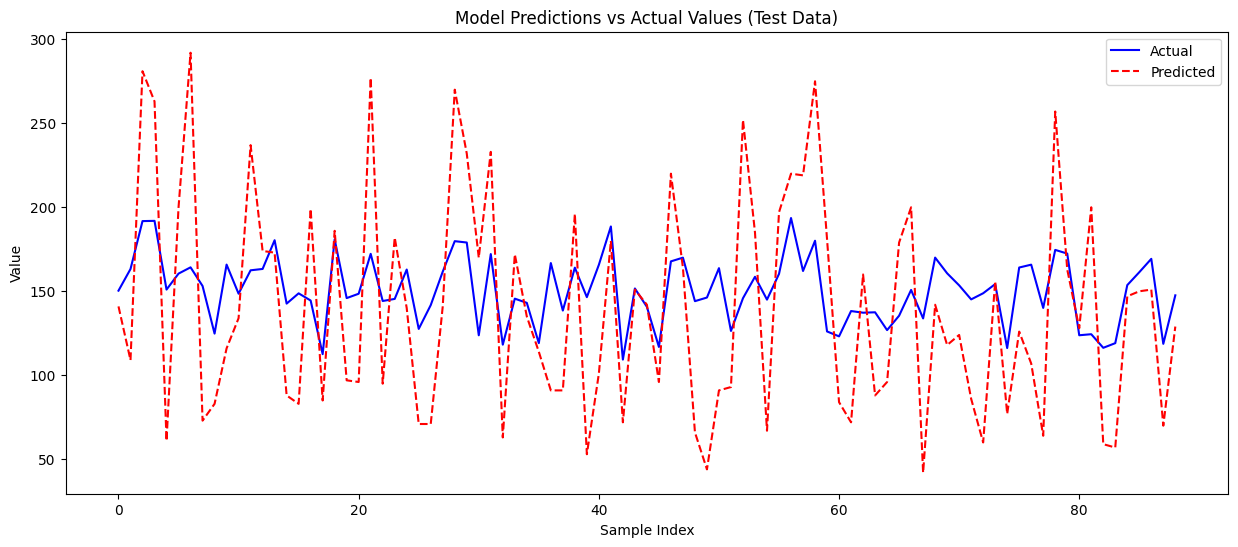

In [172]:
num_samples_to_plot = len(X_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, testPredictions[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, y_test[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

In [173]:
'''

# predictions from your ridge model
ridgeWeights = ridge(X_train_b, y_train)
testPredictions = predict(X_test_b, ridgeWeights)

# make sure these are numpy arrays
y_test_np = np.asarray(y_test)
pred_np = np.asarray(testPredictions)

# 1) True vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test_np, pred_np, alpha=0.7)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Ridge: True vs Predicted")
plt.plot([y_test_np.min(), y_test_np.max()],
         [y_test_np.min(), y_test_np.max()])
plt.show()

# 2) Residual plot
residuals = y_test_np - pred_np

plt.figure(figsize=(7, 5))
plt.scatter(pred_np, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted y")
plt.ylabel("Residual (true - pred)")
plt.title("Residual Plot")
plt.show()

# 3) Histogram of predictions
plt.figure(figsize=(7, 5))
plt.hist(pred_np, bins=20)
plt.xlabel("Predicted y")
plt.ylabel("Count")
plt.title("Distribution of Predictions")
plt.show()

# 4) Histogram of true values
plt.figure(figsize=(7, 5))
plt.hist(y_test_np, bins=20)
plt.xlabel("True y")
plt.ylabel("Count")
plt.title("Distribution of True Labels")
plt.show() '''

' \n\n# predictions from your ridge model\nridgeWeights = ridge(X_train_b, y_train)\ntestPredictions = predict(X_test_b, ridgeWeights)\n\n# make sure these are numpy arrays\ny_test_np = np.asarray(y_test)\npred_np = np.asarray(testPredictions)\n\n# 1) True vs Predicted\nplt.figure(figsize=(7, 5))\nplt.scatter(y_test_np, pred_np, alpha=0.7)\nplt.xlabel("True y")\nplt.ylabel("Predicted y")\nplt.title("Ridge: True vs Predicted")\nplt.plot([y_test_np.min(), y_test_np.max()],\n         [y_test_np.min(), y_test_np.max()])\nplt.show()\n\n# 2) Residual plot\nresiduals = y_test_np - pred_np\n\nplt.figure(figsize=(7, 5))\nplt.scatter(pred_np, residuals, alpha=0.7)\nplt.axhline(0)\nplt.xlabel("Predicted y")\nplt.ylabel("Residual (true - pred)")\nplt.title("Residual Plot")\nplt.show()\n\n# 3) Histogram of predictions\nplt.figure(figsize=(7, 5))\nplt.hist(pred_np, bins=20)\nplt.xlabel("Predicted y")\nplt.ylabel("Count")\nplt.title("Distribution of Predictions")\nplt.show()\n\n# 4) Histogram of true